# Atividade 3 - Compressão, Representação e Descrição

## Aluno: Vitor Fontenele de Oliveira Linhares - 1700778
## [Repositório](https://github.com/Vitorfol/Processamento-de-Imagens/tree/master/3)


### Imports

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
import os

### Setup

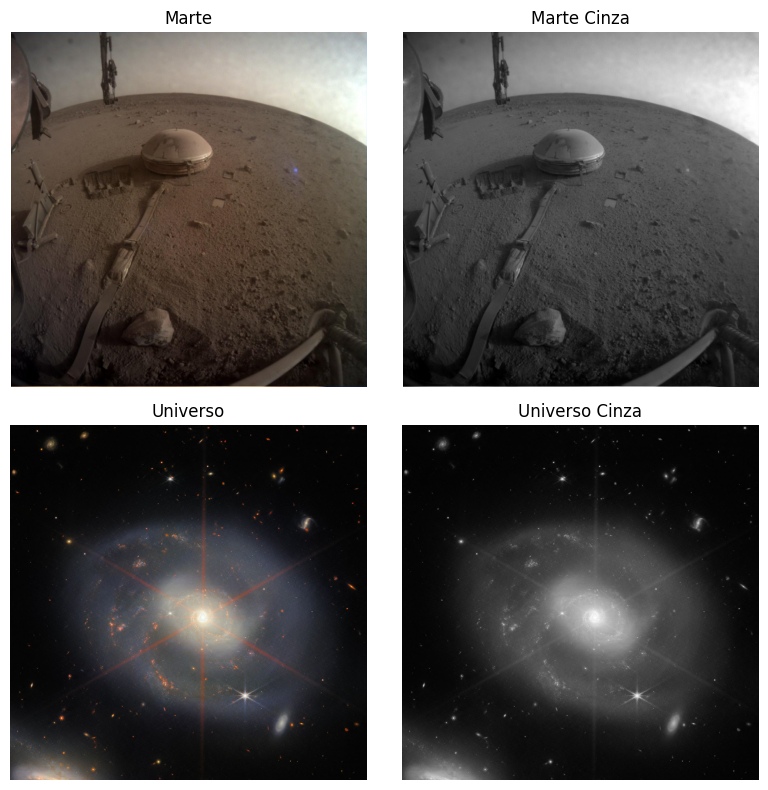

In [22]:
plt.rcParams['image.cmap'] = 'gray'

IMG1_PATH = Path('mars.jpg')
IMG2_PATH = Path('universe.jpg') 
OUT_DIR = Path('outputs')

def load_image(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f'Imagem não encontrada: {path.resolve()}')
    bgr = cv2.imread(str(path), cv2.IMREAD_UNCHANGED)
    if bgr is None:
        raise ValueError(f'Não foi possível ler a imagem: {path.resolve()}')
    if bgr.ndim == 2: 
        return bgr
    return cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

def to_gray(img):
    if img.ndim == 2: return img
    return (0.299 * img[:,:,0] + 0.587 * img[:,:,1] + 0.114 * img[:,:,2]).astype(np.float32)

def save_image(filename, img, out_dir=OUT_DIR):
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    out_path = out_dir / filename
    arr = np.clip(img, 0, 255).astype(np.uint8)
    if arr.ndim == 3:
        arr = cv2.cvtColor(arr, cv2.COLOR_RGB2BGR)
    cv2.imwrite(str(out_path), arr)
    return out_path

def show_grid(images, titles, cols, figsize=None):
    n = len(images)
    rows = (n + cols - 1) // cols
    
    if figsize is None:
        figsize = (cols * 4, rows * 4)
        
    _, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = axes.flatten() if n > 1 else [axes]
    
    for i in range(len(axes)):
        if i < n:
            axes[i].imshow(images[i], vmin=0, vmax=255)
            axes[i].set_title(titles[i])
        axes[i].axis('off')
        
    plt.tight_layout()
    plt.show()
    
def initialize():
    mars = load_image(IMG1_PATH)
    mars_gray = to_gray(mars)
    universe = load_image(IMG2_PATH)
    universe_gray = to_gray(universe)
    
    save_image('mars_gray.jpg', mars_gray, '.')
    save_image('universe_gray.jpg', universe_gray, '.')
    show_grid([mars, mars_gray, universe, universe_gray], ['Marte', 'Marte Cinza', 'Universo', 'Universo Cinza'], cols=2)

initialize()